In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import koreanize_matplotlib
from lightgbm import plot_importance
from lightgbm import LGBMClassifier
from xgboost import plot_importance
from hyperopt import fmin,tpe,Trials
from hyperopt import hp
from xgboost import XGBClassifier
from hyperopt import STATUS_OK
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix, roc_auc_score, f1_score
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

c:\anaconda3\envs\bigdata\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [74]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. 데이터 준비 및 인코딩
df = pd.read_csv("Grocery_data.csv")
df['Discount_Rate'] = (df['Price'] - df['Promoted_Price']) / df['Price']

# 카테고리를 숫자로 변환 (모델 학습용)
df_encoded = pd.get_dummies(df[['Product_Category','Discount_Rate','Total_Sales_Volume']], columns=['Product_Category'])
features = [col for col in df_encoded.columns if 'Product_Category' in col] + ['Discount_Rate']
X = df_encoded[features]
y = df_encoded['Total_Sales_Volume']

# 2. Random Forest 모델 학습
# 트리 기반 모델은 비선형 관계를 파악하는 데 매우 뛰어납니다.
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 전체 모델 R2 확인
y_pred = rf_model.predict(X)
total_r2 = r2_score(y, y_pred)
print(f"전체 모델 R2 Score (Random Forest): {total_r2:.4f}")

# 3. 카테고리별 구간 할인 효율 시뮬레이션 함수
def simulate_category_lift(category_name):
    target_col = f'Product_Category_{category_name}'
    if target_col not in df_encoded.columns: return None
    
    # 기준값 설정 (할인율 0%)
    base_input = pd.DataFrame(0, index=[0], columns=features)
    base_input[target_col] = 1
    base_input['Discount_Rate'] = 0.0
    base_sales = rf_model.predict(base_input)[0]
    
    # 구간별 시뮬레이션 (10% ~ 70%)
    discounts = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
    results = {'Base_Sales': round(base_sales, 1)}
    
    for d in discounts:
        sim_input = base_input.copy()
        sim_input['Discount_Rate'] = d
        pred_sales = rf_model.predict(sim_input)[0]
        lift = (pred_sales - base_sales) / base_sales * 100
        results[f'Lift_{int(d*100)}%'] = f"{lift:.2f}%"
        
    return pd.Series(results)

# 4. 모든 카테고리에 대해 실행
categories = df['Product_Category'].unique()
rf_lift_report = pd.DataFrame([simulate_category_lift(cat) for cat in categories if simulate_category_lift(cat) is not None])
rf_lift_report.index = [cat for cat in categories if simulate_category_lift(cat) is not None]

print("\n--- Random Forest 기반 정교한 할인 효율 리포트 ---")
display(rf_lift_report)

전체 모델 R2 Score (Random Forest): 0.4964

--- Random Forest 기반 정교한 할인 효율 리포트 ---


,Base_Sales,Lift_10%,Lift_20%,Lift_30%,Lift_40%,Lift_50%,Lift_60%,Lift_70%
Packaged Food,2951.0,-12.43%,29.10%,-3.63%,-3.63%,-3.63%,-3.63%,-3.63%
Breads,2996.3,-12.19%,-1.97%,64.21%,64.21%,64.21%,64.21%,64.21%
Frozen Foods,3010.8,-13.23%,-7.25%,8.28%,8.28%,8.28%,8.28%,8.28%
Household,2987.8,32.24%,22.94%,41.98%,41.98%,41.98%,41.98%,41.98%
Snacks,3004.3,-7.42%,-24.63%,17.12%,17.12%,17.12%,17.12%,17.12%
Vegetables,3008.1,38.42%,47.48%,14.29%,14.29%,14.29%,14.29%,14.29%
Beverages,2977.5,-7.81%,37.38%,-4.04%,-4.04%,-4.04%,-4.04%,-4.04%
Cereals,3094.8,10.78%,43.91%,-6.83%,-6.83%,-6.83%,-6.83%,-6.83%
Dairy,2890.2,42.24%,-0.76%,4.98%,4.98%,4.98%,4.98%,4.98%
Confectionery,2993.6,13.94%,18.87%,0.69%,0.69%,0.69%,0.69%,0.69%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 모델 리스트 정의
models = {
    'Linear Regression': LinearRegression(),
    'Polynomial (2nd)': None, # 별도 처리
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

results = []

# 3. 모델별 학습 및 시뮬레이션
base_case = X_test.copy()
base_case['Discount_Rate'] = 0.0
avg_base_sales = y_test.mean() # 비교 기준을 위한 실제 테스트셋 평균 판매량

for name, model in models.items():
    # 학습 및 R2 계산
    if name == 'Polynomial (2nd)':
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_p = poly.fit_transform(X_train)
        X_test_p = poly.transform(X_test)
        curr_model = LinearRegression().fit(X_train_p, y_train)
        r2 = r2_score(y_test, curr_model.predict(X_test_p))
    else:
        curr_model = model.fit(X_train, y_train)
        r2 = r2_score(y_test, curr_model.predict(X_test))
    
    # 할인 구간별 효율 시뮬레이션 (평균적인 증가율 측정)
    lifts = {}
    for d in [0.1, 0.2, 0.3, 0.5, 0.7]:
        sim_data = X_test.copy()
        sim_data['Discount_Rate'] = d
        
        if name == 'Polynomial (2nd)':
            pred = curr_model.predict(poly.transform(sim_data)).mean()
        else:
            pred = curr_model.predict(sim_data).mean()
            
        lift_pct = (pred - avg_base_sales) / avg_base_sales * 100
        lifts[f'Lift_{int(d*100)}%'] = f"{lift_pct:.2f}%"
    
    results.append({'Model': name, 'R2_Score': round(r2, 4), **lifts})

# 4. 결과 출력 및 저장
df_comparison = pd.DataFrame(results)
df_comparison.to_csv("Model_Discount_Efficiency_Comparison.csv", index=False)

print("--- 모델별 할인 효율 및 정확도 통합 비교 ---")
display(df_comparison.sort_values(by='R2_Score', ascending=False))

--- 모델별 할인 효율 및 정확도 통합 비교 ---


,Model,R2_Score,Lift_10%,Lift_20%,Lift_30%,Lift_50%,Lift_70%
1,Polynomial (2nd),0.0708,10.12%,10.73%,-9.81%,-114.31%,-303.39%
3,Gradient Boosting,0.0667,8.78%,9.88%,-7.55%,-7.55%,-7.55%
0,Linear Regression,0.0605,1.82%,12.98%,24.14%,46.47%,68.80%
5,LightGBM,0.0590,2.04%,6.12%,1.11%,1.11%,1.11%
4,XGBoost,0.0003,4.52%,7.01%,6.26%,6.26%,6.26%
2,Random Forest,-0.0543,-7.40%,8.95%,3.71%,3.71%,3.71%


=== 상관계수 분석 결과 ===
Discount_Rate와 Total_Sales_Volume의 상관계수: 0.2500


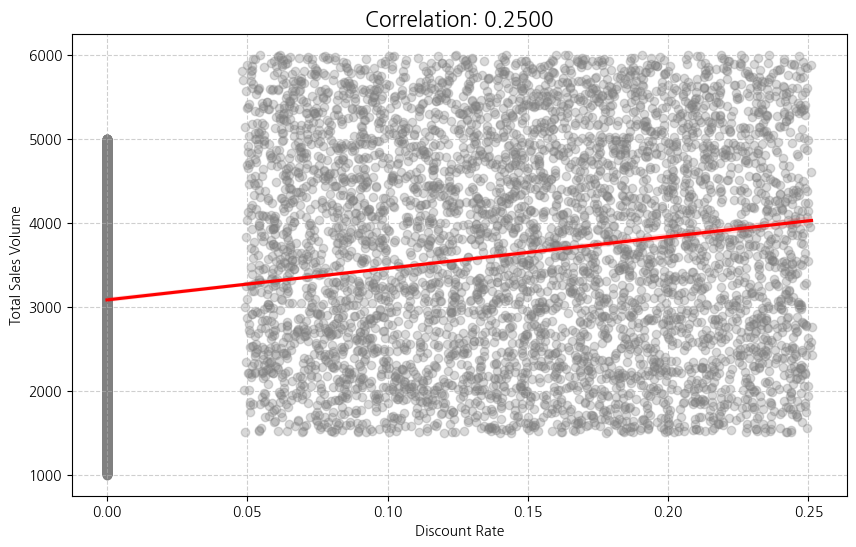

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 두 변수 간의 피어슨 상관계수 계산
correlation = df[['Discount_Rate', 'Total_Sales_Volume']].corr().iloc[0, 1]

print(f"=== 상관계수 분석 결과 ===")
print(f"Discount_Rate와 Total_Sales_Volume의 상관계수: {correlation:.4f}")

# 2. 상관관계 시각화 (산점도 + 회귀선)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Discount_Rate', y='Total_Sales_Volume', 
            scatter_kws={'alpha':0.3, 'color':'gray'}, 
            line_kws={'color':'red'})

plt.title(f'Correlation: {correlation:.4f}', fontsize=15)
plt.xlabel('Discount Rate')
plt.ylabel('Total Sales Volume')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
df = pd.read_csv('Grocery_data.csv')
display(df.groupby('Product_Category')['Price'].size())
df.groupby(['Product_Category','Price']).size()

Product_Category
Beverages        1061
Breads           1046
Cereals          1023
Confectionery    1083
Dairy            1007
Frozen Foods     1021
Household        1033
Packaged Food     993
Snacks           1099
Vegetables       1034
Name: Price, dtype: int64

Product_Category  Price
Beverages         1.51     1
                  1.52     4
                  1.54     2
                  1.55     1
                  1.56     3
                          ..
Vegetables        6.46     1
                  6.47     2
                  6.48     2
                  6.49     3
                  6.50     4
Length: 4387, dtype: int64

In [63]:
df2 = pd.read_csv('retail_price.csv')

# 2. 할인율 산정 로직 (상품별 최대가 기준)
df2['max_price'] = df2.groupby('product_id')['unit_price'].transform('max')
df2['discount_rate'] = (df2['max_price'] - df2['unit_price']) / df2['max_price']

# 3. 요청사항 반영: unit_price가 같은 경우 qty를 평균 내어 계산
# 동일 상품(product_id) 내에서 동일 가격(unit_price)인 경우들의 qty 평균 계산
grouped = df2.groupby(['product_id', 'unit_price', 'discount_rate'])['qty'].mean().reset_index()
display(grouped)
# 4. 전체 데이터에 대한 회귀 분석 수행
data = grouped[['discount_rate']]
target = grouped['qty']
# 4. 전체 데이터에 대한 회귀 분석 수행

X_train,X_test,y_train,y_test = train_test_split(data,target,test_size=0.2,random_state=42)


,product_id,unit_price,discount_rate,qty
0,bed1,39.240000,0.146028,8.000000
1,bed1,39.990000,0.129706,13.125000
2,bed1,40.531818,0.117915,11.000000
3,bed1,45.950000,0.000000,3.166667
4,bed2,74.000000,0.176863,7.000000
...,...,...,...,...
324,watches8,157.945455,0.341620,11.000000
325,watches8,167.500000,0.301792,16.000000
326,watches8,204.618182,0.147069,11.000000
327,watches8,229.900000,0.041684,2.000000


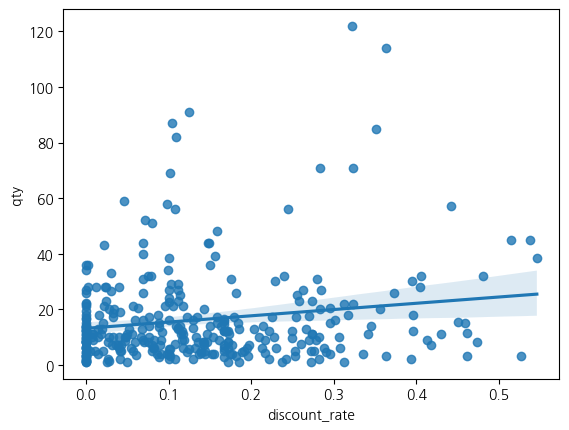

In [ ]:
sns.regplot(x = data,y= target[target])
plt.show()

In [61]:

# 2. 모델 리스트 정의
models = {
    'Linear Regression': LinearRegression(),
    'Polynomial (2nd)': None, # 별도 처리
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1,verbose=-1)
}

results = []

# 3. 모델별 학습 및 시뮬레이션
base_case = X_test.copy()
base_case['discount_rate'] = 0.0
avg_base_sales = y_test.mean() # 비교 기준을 위한 실제 테스트셋 평균 판매량

for name, model in models.items():
    # 학습 및 R2 계산
    if name == 'Polynomial (2nd)':
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_p = poly.fit_transform(X_train)
        X_test_p = poly.transform(X_test)
        curr_model = LinearRegression().fit(X_train_p, y_train.values.ravel())
        r2 = r2_score(y_test, curr_model.predict(X_test_p))
    else:
        curr_model = model.fit(X_train, y_train.values.ravel())
        r2 = r2_score(y_test, curr_model.predict(X_test))
    
    # 할인 구간별 효율 시뮬레이션 (평균적인 증가율 측정)
    lifts = {}
    for d in [0.1, 0.2,0.3,0.4,0.5,0.6,0.7]:
        sim_data = X_test.copy()
        sim_data['discount_rate'] = d
        
        if name == 'Polynomial (4th)':
            pred = curr_model.predict(poly.transform(sim_data)).mean()
        else:
            pred = curr_model.predict(sim_data).mean()
            
        lift_pct = (pred - avg_base_sales) / avg_base_sales * 100
        lifts[f'Lift_{int(d*100)}%'] = lift_pct
    
    results.append({'Model': name, 'R2_Score': round(r2, 4), **lifts})

# 4. 결과 출력 및 저장
df_comparison = pd.DataFrame(results)

print("--- 모델별 할인 효율 및 정확도 통합 비교 ---")
display(df_comparison.sort_values(by='R2_Score', ascending=False))

c:\anaconda3\envs\bigdata\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

In [47]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 데이터 로드
df = pd.read_csv('retail_price.csv')

# 1. 간단한 할인율 지표 생성 (예: 기준가 대비 현재가)
# 여기서는 예시로 unit_price와 lag_price의 차이를 활용합니다.
df['discount_amount'] = df['lag_price'] - df['unit_price']
df['discount_rate'] = (df['discount_amount'] / df['lag_price']) * 100

# 2. 결측치 제거
df_clean = df[['discount_rate', 'qty']].dropna()

# 3. 회귀 분석 모델링
X = df_clean[['discount_rate']].values
y = df_clean['qty'].values

model = LinearRegression()
model.fit(X, y)

# 4. R^2 및 결과 출력
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"결정계수 (R^2): {r2:.4f}")
print(f"회귀 계수 (기울기): {model.coef_[0]:.4f}")

결정계수 (R^2): 0.0309
회귀 계수 (기울기): 0.3960


In [48]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 데이터 로드 및 전처리
df = pd.read_csv('retail_price.csv')
df['discount_rate'] = ((df['lag_price'] - df['unit_price']) / df['lag_price']) * 100

# 2. 카테고리별로 분석을 수행할 함수 정의
def analyze_by_category(group):
    group = group[['discount_rate', 'qty']].dropna()
    if len(group) < 10: # 데이터 개수가 너무 적으면 제외
        return None
    
    X = group[['discount_rate']].values
    y = group['qty'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    r2 = r2_score(y, model.predict(X))
    slope = model.coef_[0]
    
    return pd.Series({'R2': r2, 'Slope': slope, 'Count': len(group)})

# 3. 카테고리별 그룹 분석 적용
category_results = df.groupby('product_category_name').apply(analyze_by_category).dropna()

# 4. R2가 높은 순서대로 정렬하여 출력
category_results = category_results.sort_values(by='R2', ascending=False)
print("--- 상품 카테고리별 할인 효율 분석 ---")
print(category_results)

--- 상품 카테고리별 할인 효율 분석 ---
                             R2     Slope  Count
product_category_name                           
computers_accessories  0.185165  1.077588   69.0
consoles_games         0.076951 -0.374158   22.0
watches_gifts          0.074505  0.540024  103.0
furniture_decor        0.047349  0.855371   48.0
garden_tools           0.021653  0.340270  160.0
bed_bath_table         0.014728  0.587577   61.0
health_beauty          0.009065 -0.386377  130.0
cool_stuff             0.001185  0.032788   57.0
perfumery              0.001180  0.055263   26.0


C:\Users\KDS12\AppData\Local\Temp\ipykernel_24456\2548465361.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_results = df.groupby('product_category_name').apply(analyze_by_category).dropna()


In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 데이터 로드
df2 = pd.read_csv('retail_price.csv')

# 2. 상품별 최대 가격(기준가) 계산 및 할인율 산출
# transform을 사용하면 루프를 돌지 않아도 각 행에 맞는 max_price를 바로 매칭할 수 있습니다.
df2['max_price'] = df2.groupby('product_id')['unit_price'].transform('max')
df2['discount_rate'] = (df2['max_price'] - df2['unit_price']) / df2['max_price']

# 3. 카테고리별 분석 수행
results = []
for cat in df2['product_category_name'].unique():
    cat_df = df2[df2['product_category_name'] == cat].copy()
    
    # 데이터가 너무 적으면 신뢰도가 낮으므로 제외 (최소 10개 이상)
    if len(cat_df) < 10:
        continue
        
    X = cat_df[['discount_rate']]
    y = cat_df['qty']
    
    # 학습/테스트 데이터 분리 (8:2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 선형 회귀 모델 학습
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 결과 평가
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Category': cat,
        'R2': r2,
        'Slope': model.coef_[0],
        'Count': len(cat_df)
    })

# 4. 결과 출력 (R2 기준 내림차순)
analysis_result = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(analysis_result)

                Category        R2       Slope  Count
8        furniture_decor  0.407505  129.824344     48
7          watches_gifts  0.336180   26.436222    103
2         consoles_games  0.292460   30.145909     22
1           garden_tools -0.037401  -10.954290    160
0         bed_bath_table -0.066187  -15.886474     61
6  computers_accessories -0.097272   12.318330     69
3          health_beauty -0.164517   -9.431760    130
4             cool_stuff -0.431065   29.646701     57
5              perfumery -0.715452   -2.546484     26


In [ ]:
df = pd.read_csv('retail_price.csv')

# 2. 할인율 산정 로직 (상품별 최대가 기준)
df['max_price'] = df.groupby('product_id')['unit_price'].transform('max')
df['discount_rate'] = (df['max_price'] - df['unit_price']) / df['max_price']

# 3. 요청사항 반영: unit_price가 같은 경우 qty를 평균 내어 계산
# 동일 상품(product_id) 내에서 동일 가격(unit_price)인 경우들의 qty 평균 계산
grouped = df.groupby(['product_id', 'unit_price', 'discount_rate'])['qty'].mean().reset_index()

# 4. 전체 데이터에 대한 회귀 분석 수행
X = grouped[['discount_rate']]
y = grouped['qty']

model = LinearRegression()
model.fit(X, y)